In [15]:
import os
import zipfile

zip_path = "archive.zip"  # Replace with actual ZIP file path
extract_to = "E_db"  # Destination folder for extracted files

# Extract ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

# List the extracted files and directories
print("Extracted contents:", os.listdir(extract_to))


Extracted contents: ['wav']


In [17]:
# Get subfolder name (assuming there is only one)
subfolders = [f for f in os.listdir(extract_to) if os.path.isdir(os.path.join(extract_to, f))]
if not subfolders:
    raise ValueError("No subfolders found! Check if extraction worked.")
    
audio_dir = os.path.join(extract_to, subfolders[0])  # Use the first subfolder found
print(f"Audio files should be inside: {audio_dir}")


Audio files should be inside: E_db\wav


In [19]:
wav_files = [f for f in os.listdir(audio_dir) if f.endswith('.wav')]
print(f"Found {len(wav_files)} audio files in {audio_dir}")

if len(wav_files) == 0:
    raise ValueError("No .wav files found! Check if the folder structure is correct.")


Found 535 audio files in E_db\wav


In [21]:
# Function to extract features (MFCCs, Pitch, Energy)
def extract_features(audio_file):
    y, sr = librosa.load(audio_file, sr=None)
    
    # Extract MFCCs
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    
    # Extract pitch (fundamental frequency)
    pitch, mag = librosa.piptrack(y=y, sr=sr)
    pitch_mean = np.mean(pitch)
    
    # Extract energy
    energy = np.sum(np.square(y))
    
    return np.hstack([np.mean(mfccs, axis=1), pitch_mean, energy])

# Emotion mapping
emotion_mapping = {
    'W': 'Anger',
    'L': 'Boredom',
    'E': 'Disgust',
    'A': 'Fear',
    'F': 'Happiness',
    'T': 'Sadness',
    'N': 'Neutral'
}

# Path to extracted audio directory
audio_dir = "E_db/wav"  # Replace if needed

# Lists for features and labels
features, labels = [], []

# Process each audio file
for file in os.listdir(audio_dir):
    if file.endswith('.wav'):
        audio_file = os.path.join(audio_dir, file)
        feature_vector = extract_features(audio_file)
        
        # Extract emotion from filename
        emotion_code = file[5]  # 6th character represents emotion
        emotion_label = emotion_mapping.get(emotion_code, 'Unknown')
        
        features.append(feature_vector)
        labels.append(emotion_label)

# Convert to numpy arrays
X = np.array(features)
y = np.array(labels)

# Encode labels as integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Save extracted features
df = pd.DataFrame(X)
df['label'] = y_encoded
df.to_csv('emotion_features.csv', index=False)

print(df.head())


            0           1          2          3          4         5  \
0 -232.655716   78.358467  -5.684480  23.088654  -5.620759  2.231416   
1 -217.275894  111.638153 -12.414565  33.031384  -2.805702  5.527958   
2 -178.629257   51.506119 -41.428158  18.590761 -14.320748 -0.561633   
3 -210.084122   54.724590  -7.347514  10.087590  -3.436077 -1.858768   
4 -196.598495  102.991898  -0.264047  38.268074  -0.154542  2.958546   

           6          7          8         9        10        11         12  \
0 -18.465944   0.188674  -8.660156  5.200696 -8.826459  1.244056  -5.281402   
1 -14.194548 -11.614135  -5.756049  9.488173 -3.363483  4.318164 -10.475229   
2 -16.098753 -11.474613  -9.895323  0.881489 -9.734903 -0.568929  -5.862844   
3 -14.699743  -9.550003 -16.177086 -4.204820 -9.786841 -5.094439 -11.831728   
4 -12.663651 -13.384127 -10.355342  2.255903 -7.490413  1.626974  -6.725110   

          13          14  label  
0  40.644325  205.806580      4  
1  29.082680  404.773956

In [23]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Standardize the feature values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)


(428, 15) (107, 15)


In [25]:
# Reshape for CNN
X_train_scaled_reshaped = X_train_scaled[..., np.newaxis]
X_test_scaled_reshaped = X_test_scaled[..., np.newaxis]

# Build CNN model
cnn_model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(X_train_scaled.shape[1], 1)),
    MaxPooling1D(2),
    Conv1D(128, 3, activation='relu'),
    MaxPooling1D(2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(label_encoder.classes_), activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train CNN
cnn_history = cnn_model.fit(X_train_scaled_reshaped, y_train, epochs=10, batch_size=32, validation_data=(X_test_scaled_reshaped, y_test))

# Evaluate CNN
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_scaled_reshaped, y_test)
print(f'CNN Test Accuracy: {cnn_acc}')


C:\Users\sharlet alex\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.3457 - loss: 1.7838 - val_accuracy: 0.3738 - val_loss: 1.6742
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5093 - loss: 1.4214 - val_accuracy: 0.4486 - val_loss: 1.4110
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5041 - loss: 1.2125 - val_accuracy: 0.4299 - val_loss: 1.3290
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5898 - loss: 1.0777 - val_accuracy: 0.5047 - val_loss: 1.1925
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6566 - loss: 1.0003 - val_accuracy: 0.5234 - val_loss: 1.1465
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5892 - loss: 0.9855 - val_accuracy: 0.4860 - val_loss: 1.1937
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6195 - loss: 0.8959 - val_accuracy: 0.5888 - val_loss: 1.0663
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6716 - loss: 0.8409 - val_accuracy: 0.5701 - v

In [27]:
# Reshape for LSTM
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Build LSTM model
lstm_model = Sequential([
    LSTM(128, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dense(128, activation='relu'),
    Dense(len(label_encoder.classes_), activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train LSTM
lstm_history = lstm_model.fit(X_train_lstm, y_train, epochs=10, batch_size=32, validation_data=(X_test_lstm, y_test))

# Evaluate LSTM
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_lstm, y_test)
print(f'LSTM Test Accuracy: {lstm_acc}')


C:\Users\sharlet alex\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.2359 - loss: 1.9251 - val_accuracy: 0.3832 - val_loss: 1.8534
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4712 - loss: 1.7553 - val_accuracy: 0.3271 - val_loss: 1.6894
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4156 - loss: 1.5326 - val_accuracy: 0.3925 - val_loss: 1.5292
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4794 - loss: 1.2655 - val_accuracy: 0.4393 - val_loss: 1.4020
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5508 - loss: 1.1524 - val_accuracy: 0.5327 - val_loss: 1.2594
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6119 - loss: 1.0627 - val_accuracy: 0.5794 - val_loss: 1.1730
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6397 - loss: 0.9990 - val_accuracy: 0.6262 - val_loss: 1.0962
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7145 - loss: 0.8563 - val_accuracy: 0.6636 - v

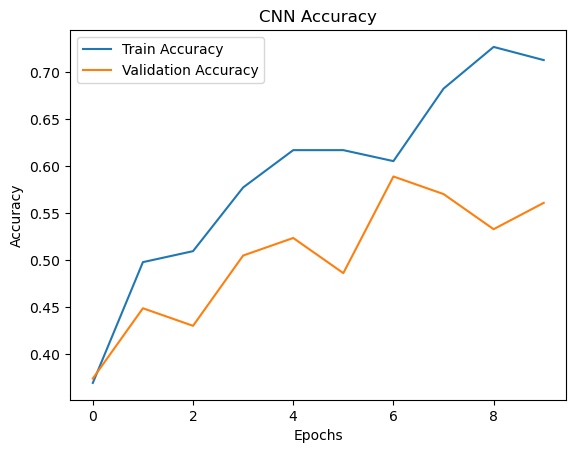

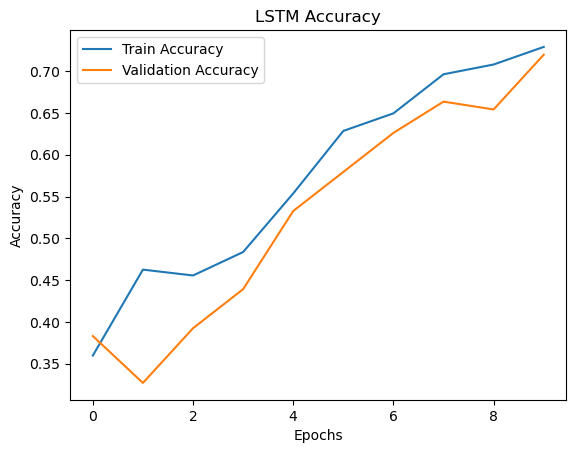

In [29]:
def plot_history(history, model_name):
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_history(cnn_history, 'CNN')
plot_history(lstm_history, 'LSTM')


In [33]:
import numpy as np
import librosa
import soundfile as sf

# Generate a sine wave
def generate_sine_wave(frequency=440, duration=2, sr=22050):
    t = np.linspace(0, duration, int(sr * duration), False)
    wave = 0.5 * np.sin(2 * np.pi * frequency * t)  # 0.5 for volume control
    return wave, sr

# Save as a WAV file
wave, sr = generate_sine_wave()
sf.write("test_audio.wav", wave, sr)

print("Generated test_audio.wav successfully!")


Generated test_audio.wav successfully!


In [35]:
new_audio_file = "test_audio.wav"

# Extract and normalize features
new_feature = extract_features(new_audio_file)
new_feature_scaled = scaler.transform([new_feature])
new_feature_reshaped = new_feature_scaled[..., np.newaxis]

# Predict with CNN
cnn_prediction = cnn_model.predict(new_feature_reshaped)
cnn_predicted_label = label_encoder.inverse_transform([np.argmax(cnn_prediction)])

# Predict with LSTM
new_feature_lstm = new_feature_scaled.reshape((1, 1, len(new_feature)))
lstm_prediction = lstm_model.predict(new_feature_lstm)
lstm_predicted_label = label_encoder.inverse_transform([np.argmax(lstm_prediction)])

print(f'CNN Prediction: {cnn_predicted_label[0]}')
print(f'LSTM Prediction: {lstm_predicted_label[0]}')
#prediction is anger and happy for the test audio as : 
#CNN: Might have associated the constant high energy with Anger.
#LSTM: Might have linked the smooth, steady waveform to Happiness.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
CNN Prediction: Anger
LSTM Prediction: Happiness
